# Estatística 1 - Aula prática 1_3 em Python

## UNIDADE 1: Estatística descritiva

### Seção 1.3: Séries estatísticas, gráficos e tabelas

By Jose P. Leitão

In [32]:
%matplotlib inline
# Importar bibliotecas
import plotly.express as px

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib_inline.backend_inline

# Define o formato de saída para SVG
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import pandas as pd

import numpy as np

import warnings
warnings.filterwarnings('ignore')

#### Gráfico de Linhas

In [ ]:
# Carrega a base economics
economics = pd.read_excel("economics.xlsx")

In [ ]:
# Exibe os primeiros registros
economics.head()

In [ ]:
# Cria um gráfico de linha date x unemploy com uma linha de tendência LOWESS (Locally Weighted Scatterplot Smoothing)
fig = px.scatter(economics, # Dataframe
                 x="date", y="unemploy",  # eixos X e Y
                 trendline="lowess", # Linha de Tendência
                 width=800, height=500, # Tamanho da figura em Pixel
                 template="ggplot2", # usa o template ggplot2
                 title="Titulo" # Título da figura
                 )

# Muda a cor da linha
fig.update_traces(mode="lines", line=dict(color="black"))

# Modifica o formato dos números no eixo y
fig.update_yaxes(tickformat=",.0f")

# Desenha o box em torno do gráfico
fig.update_xaxes(showline=True, linewidth=1, linecolor="black", mirror=True)
fig.update_yaxes(showline=True, linewidth=1, linecolor="black", mirror=True)

fig.update_layout(
    showlegend=True,
    xaxis=dict(
        tickformat="%Y", # só mostra o ano
        dtick="M24", # um 'tick' a cada 24 meses
        tickangle=0, # angulo dos valores do eixo
        showgrid=True,
        gridcolor="lightgray",
        gridwidth=1,
        griddash="dot"
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor="lightgray",
        gridwidth=1,
        griddash="dot"
    )
)
fig.show()

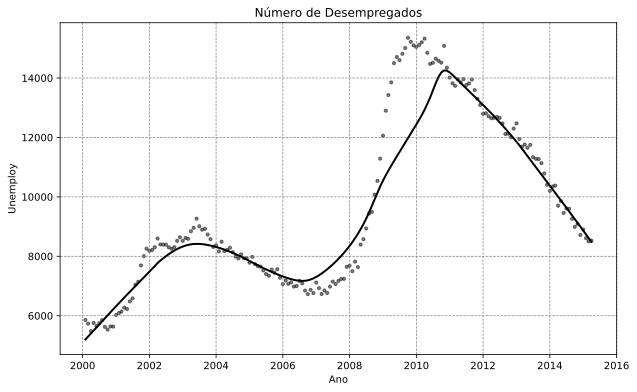

In [33]:
from statsmodels.nonparametric.smoothers_lowess import lowess

# 1. Obter os dados
x = economics['date']
y = economics['unemploy']

# Converter para float (segundos desde epoch)
x_num = x.astype('int64') / 1e9

# 2. Calcular a curva LOWESS
# frac: Fração dos dados usados para suavizar (padrão é 2/3, valores menores = menos suave)
smoothed = lowess(y, x_num, frac=0.3)

# 3. Plotar os dados e a curva
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label='Dados Originais', alpha=0.5, s=10, color='black')
plt.plot(x, smoothed[:, 1], label='Curva LOWESS', linewidth=2, color='black')

plt.title('Número de Desempregados')
plt.ylabel("Unemploy")
plt.xlabel(("Ano"))
#plt.legend()
plt.grid(True, color='gray', linestyle='--', linewidth=0.7,)

plt.show()


#### Outro Exemplo

In [ ]:
# Carrega a base de dados de cotação da ação PETR4
basepetr4 = pd.read_excel("basepetr4.xlsx")

In [ ]:
# Gráfico mostrando o preço de fechamento em cada mês

fig = px.line(basepetr4, x="Data", y="Fechamento", 
                 width=800, height=500, template="ggplot2", title="Preço Fechamento PETR4", 
                 color_discrete_sequence=px.colors.sequential.Viridis)

# Modifica o formato dos números no eixo y
fig.update_yaxes(tickformat=",.2f")

# Desenha o box em torno do gráfico
fig.update_xaxes(showline=True, linewidth=1, linecolor="black", mirror=True)
fig.update_yaxes(showline=True, linewidth=1, linecolor="black", mirror=True)

# Faz ajustes no layout
fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(
        tickformat="%m-%Y", # apresenta a legenda no formato mês-ano
        dtick="M1", # Intervalo do tick, a cada mês
        tickangle=90), # rotaciona a legenda do eixo x
    yaxis_title="(R$)", # formata os dados no eixo y
    xaxis_title="Mês/Ano" # Título do gráfico
    )

fig.show()

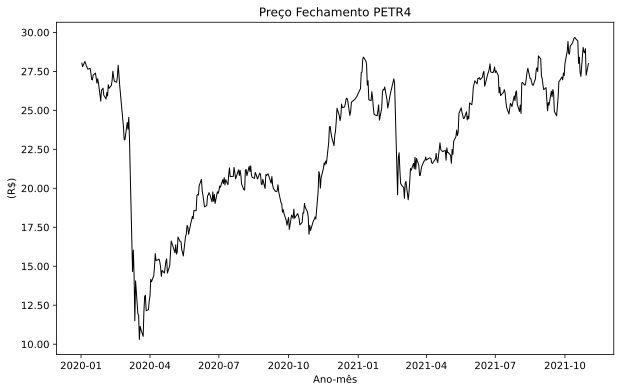

In [34]:
# 1. Obter os dados
x = basepetr4['Data']
y = basepetr4['Fechamento']

# 2. Plotar o gráfico
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(x, y, linewidth=1, color='black')

# Formatar os eixos
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:.2f}'))
ax.set_ylabel("(R$)")
ax.set_xlabel("Ano-mês")

# Coloca o título
plt.title('Preço Fechamento PETR4')

plt.show()

#### Gráfico de Dispersão

In [ ]:
# Carrega a base ceo.txt
ceo = pd.read_csv("ceo.txt", sep=' ')

In [ ]:
# Exibe os primeiros registros
ceo.head()

In [ ]:
# Cria um gráfico de dispersão age x comten
fig = px.scatter(ceo, x="age", y="comten", width=600, height=800  )

# Desenha o box em torno do gráfico
fig.update_xaxes(showline=True, linewidth=1, linecolor="black", mirror=True)
fig.update_yaxes(showline=True, linewidth=1, linecolor="black", mirror=True)

# Faz algumas alterações no layout
fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(showgrid=False), # Desliga o grid horizontal
    yaxis=dict(showgrid=False), # Desliga o grid vertical
    title="Titulo", # Título da figura
    title_x=0.5) # Centraliza o título

fig.show()

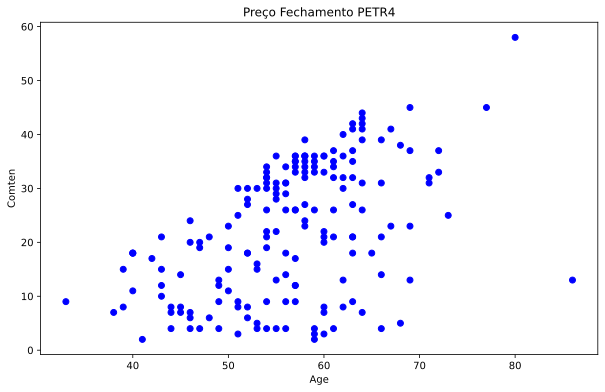

In [35]:
# Cria um gráfico de dispersão age x comten

# 1. Obter os dados
x = ceo['age']
y = ceo['comten']

# 2. Plotar o gráfico
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(x, y,  color='blue')
ax.set_ylabel("Comten")
ax.set_xlabel("Age")

plt.title('Preço Fechamento PETR4')

plt.show()

#### Histograma

In [ ]:
# Carrega a base salarios
salarios = pd.read_csv("salarios.csv")


In [ ]:
# Exibe os primeiros registros
salarios.head()

In [ ]:
# Apresenta sumário da base
salarios.describe()
#salarios.info()

In [ ]:
# Criar histograma de idade dos maridos (número de bins manualmente definido)
fig = px.histogram(salarios, x='husage',  nbins=5,
                   text_auto=True, width=800, height=500, title="Distribuição das Idades dos Maridos")

# Espaçamento entre as colunas
fig.update_layout(bargap=0.2,
                xaxis_title="Idade",
                yaxis_title="Frequência",)

fig.show()

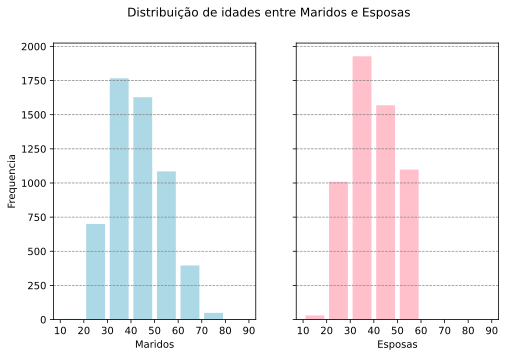

In [51]:
# Histograma usando Matplotlib com hist()
# define as faixas de interesse
faixas = [10, 20, 30, 40, 50, 60, 70, 80, 90]

# define as séries de interesse, rótulos e cores
colunas = [salarios['husage'], salarios['age']]
labels = ['Maridos', 'Esposas']
colors = ['lightblue', 'pink']

# cria figura e subplots
fig, axs = plt.subplots(1, 2, sharey=True, figsize=(8,5))

# estiliza para todas os subplots
for i in range(len(colunas)):
    axs[i].hist(colunas[i], bins=faixas, color=colors[i], rwidth=0.8) # cria o histograma com espaçamento entre os bins
    axs[i].set_xlabel(labels[i]) # define o rótulo da séria
    axs[i].set_facecolor('white') # cor de fundo de gráfico
    axs[i].grid(color='gray', linestyle='--', linewidth=0.7, axis='y') # seta apenas linhas de grades horizontais
    axs[i].set_xticks(faixas) # apresenta os xticks de acordo com os bins

axs[0].set_ylabel("Frequencia") # título do eixo Y apenas no gráfico da esquerda

fig.suptitle("Distribuição de idades entre Maridos e Esposas") # título da figura

plt.show()

In [ ]:
# Número de bins pelo método de Sturges (k = 1 + 3,32*log10(n) onde n é o número de amostras)
n = salarios['husage'].count()
k = round(1 + 3.32 * np.log10(n),0)
print(k)

#### Boxplot

In [ ]:
# Cria um gráfico de Boxplot
fig = px.box(salarios, y="age", width=800, height=500, color_discrete_sequence=["green"])

fig.show()

In [ ]:
# Boxplot de duas séries
fig = px.box(salarios, y=['husage', 'age'], # define as colunas
             width=800, height=500, # tamanho do desenho
             color='variable', # cada box é de uma cor diferente
             labels={"variable": "Gêneros", "value": "Idade"}, # altera os nomes dos eixos
             color_discrete_sequence=["blue", "pink"]) # define a cor para cada box

# Renomeia os nomes das legendas
fig.data[0].name = 'maridos'
fig.data[1].name = 'esposas'

# Desenha um box em torno do gráfico
fig.update_xaxes(showline=True, linewidth=1, linecolor="black", mirror=True)
fig.update_yaxes(showline=True, linewidth=1, linecolor="black", mirror=True)

# Altera as cores do fundo e o título do gráfico
fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    title="Titulo", # Título da figura
    title_x=0.5) # Centraliza o título

fig.show()


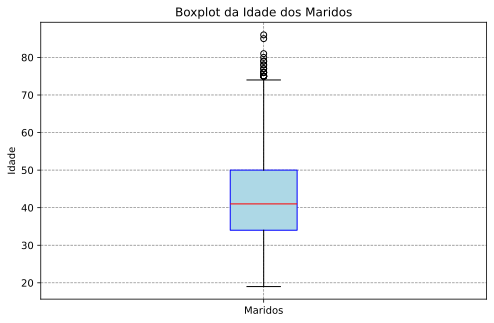

In [ ]:
# Usando matplotlib com boxplot

fig, ax = plt.subplots(figsize=(8,5))
ax.set_ylabel('Idade')
ax.set_title("Boxplot da Idade dos Maridos")

ax.boxplot(salarios['husage'],
                   patch_artist=True,  # fill with color
                   tick_labels=['Maridos'],
                   boxprops=dict(facecolor='lightblue', color='blue'),
                   medianprops=dict(color='red')
                   )  # will be used to label x-ticks

ax.grid(True, color="gray", linestyle="--", linewidth=0.7)

plt.show()

#### Tabela de Distribuição de Frequência

In [ ]:
# Criar uma tabela de distribuição de frequencia
# Dataframe: salarios
# Serie: husearns
# Número de bins é definido usando o método de Sturges num_bins = 1 + 3,32 * log(n)
# Número de bins pode ser um número inteiro a conveniência do usuário
freq, faixas = np.histogram(salarios['husearns'],bins='sturges')
print(freq, faixas)



In [ ]:
# Criar uma tabela de distribuição de densidade de probabilidade
# Dataframe: salarios
# Serie: husearns
# Número de bins é definido usando o método de Sturges num_bins = 1 + 3,32 * log(n)
# Número de bins pode ser um número inteiro a conveniência do usuário
densidades, faixas = np.histogram(salarios['husearns'],bins='sturges', density=True)
print(densidades, faixas)